# 03: Preprocessing & Sequence Creation - Smart Grid Load Forecasting

## Objective
Normalize data and create sliding window sequences for time-series deep learning models.

## Tasks
- Normalize data using MinMaxScaler
- Create sliding window sequences (lookback=24 hours)
- Create input shape (samples, 24, features)
- Split data: 70% train, 15% validation, 15% test
- Save processed data and scalers

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

# Set random seed for reproducibility
np.random.seed(42)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 1: Load Engineered Features

In [2]:
# Load engineered features
df = pd.read_csv('../data/AEP_engineered.csv', index_col='Datetime', parse_dates=True)

print('Data loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
print(df.head())

Data loaded successfully!
Shape: (121273, 15)

Columns: ['AEP_MW', 'hour', 'day_of_week', 'month', 'day_of_year', 'weekend_flag', 'quarter', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day', 'sin_year', 'cos_year']

First 5 rows:
                      AEP_MW  hour  day_of_week  month  day_of_year  \
Datetime                                                              
2004-12-31 01:00:00  13478.0     1            4     12          366   
2004-12-31 02:00:00  12865.0     2            4     12          366   
2004-12-31 03:00:00  12577.0     3            4     12          366   
2004-12-31 04:00:00  12517.0     4            4     12          366   
2004-12-31 05:00:00  12670.0     5            4     12          366   

                     weekend_flag  quarter  sin_hour  cos_hour     sin_month  \
Datetime                                                                       
2004-12-31 01:00:00             0        4  0.258819  0.965926 -2.449294e-16   
2004-12-31

## Step 2: Normalize Data

### Why Normalization?
Different features have different scales:
- Load (AEP_MW): 4000-7000 MW
- Binary features (weekend_flag): 0-1
- Sin/Cos features: -1 to 1

**Solution:** MinMaxScaler scales all features to [0, 1] range
- Helps neural networks train faster
- Prevents features with large scales from dominating
- Improves gradient flow during backpropagation

In [3]:
# Create scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalize all features
data_normalized = scaler.fit_transform(df)

print('Data normalized successfully!')
print(f'\nNormalized data shape: {data_normalized.shape}')
print(f'Normalized data range: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]')

# Create DataFrame with normalized data
df_normalized = pd.DataFrame(data_normalized, columns=df.columns, index=df.index)
print(f'\nFirst 5 rows of normalized data:')
print(df_normalized.head())

# Check statistics
print(f'\nNormalized data statistics:')
print(df_normalized.describe())

Data normalized successfully!

Normalized data shape: (121273, 15)
Normalized data range: [0.0000, 1.0000]

First 5 rows of normalized data:
                       AEP_MW      hour  day_of_week  month  day_of_year  \
Datetime                                                                   
2004-12-31 01:00:00  0.241839  0.043478     0.666667    1.0          1.0   
2004-12-31 02:00:00  0.203798  0.086957     0.666667    1.0          1.0   
2004-12-31 03:00:00  0.185925  0.130435     0.666667    1.0          1.0   
2004-12-31 04:00:00  0.182202  0.173913     0.666667    1.0          1.0   
2004-12-31 05:00:00  0.191697  0.217391     0.666667    1.0          1.0   

                     weekend_flag  quarter  sin_hour  cos_hour  sin_month  \
Datetime                                                                    
2004-12-31 01:00:00           0.0      1.0  0.629410  0.982963        0.5   
2004-12-31 02:00:00           0.0      1.0  0.750000  0.933013        0.5   
2004-12-31 03:00:0

## Step 3: Visualize Before & After Normalization

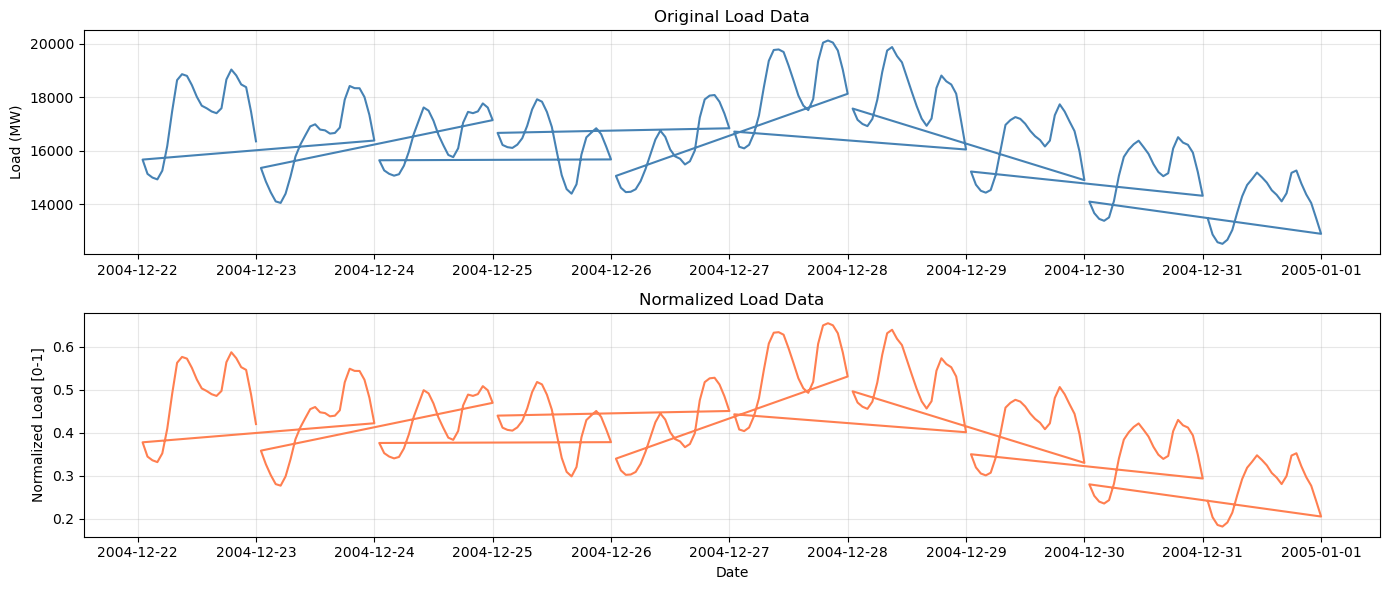

Normalization visualization completed!


In [4]:
# Compare original vs normalized load
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Original data (first 240 hours = 10 days)
axes[0].plot(df.index[:240], df['AEP_MW'].values[:240], linewidth=1.5, color='steelblue')
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('Original Load Data')
axes[0].grid(True, alpha=0.3)

# Normalized data
axes[1].plot(df.index[:240], df_normalized['AEP_MW'].values[:240], linewidth=1.5, color='coral')
axes[1].set_ylabel('Normalized Load [0-1]')
axes[1].set_xlabel('Date')
axes[1].set_title('Normalized Load Data')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Normalization visualization completed!')

## Step 4: Create Sliding Window Sequences

### What is Sequence Creation?
Time-series models need multiple time steps as input to predict the next value.

**Configuration:**
- **Lookback window:** 24 hours (past 24 hours of data)
- **Prediction horizon:** 1 hour (predict next hour's load)

**Example:**
```
Input sequence [t-23, t-22, ..., t-1, t] -> Prediction [t+1]
```

For each time step `t`, we take previous 24 hours of all features as input
and the load at time `t+1` as the target.

In [5]:
def create_sequences(data, lookback=24):
    """
    Create sequences for time-series modeling.
    
    Args:
        data: Normalized data array (samples, features)
        lookback: Number of previous time steps to use (default=24)
    
    Returns:
        X: Input sequences (samples, lookback, features)
        y: Target values (samples,)
    """
    X, y = [], []
    
    for i in range(len(data) - lookback):
        # Input: 24 hours of all features
        X.append(data[i:i+lookback, :])  # Shape: (24, num_features)
        # Target: Load at t+1 (column 0 is AEP_MW)
        y.append(data[i+lookback, 0])  # Scalar value
    
    return np.array(X), np.array(y)

# Create sequences
lookback = 24
X, y = create_sequences(data_normalized, lookback=lookback)

print(f'Sequences created successfully!')
print(f'\nInput shape (X): {X.shape}')
print(f'  - Samples: {X.shape[0]}')
print(f'  - Time steps (hours): {X.shape[1]}')
print(f'  - Features: {X.shape[2]}')
print(f'\nTarget shape (y): {y.shape}')
print(f'\nExample - First sequence and target:')
print(f'X[0] shape (first sequence): {X[0].shape}')
print(f'Target y[0]: {y[0]:.4f}')

Sequences created successfully!

Input shape (X): (121249, 24, 15)
  - Samples: 121249
  - Time steps (hours): 24
  - Features: 15

Target shape (y): (121249,)

Example - First sequence and target:
X[0] shape (first sequence): (24, 15)
Target y[0]: 0.2803


## Step 5: Split Data - 70% Train, 15% Validation, 15% Test

### Data Split Strategy
For time-series data, we use chronological split (not random shuffle):
- **Training set:** First 70% - learn patterns from historical data
- **Validation set:** Next 15% - tune hyperparameters without touching test
- **Test set:** Last 15% - final evaluation on unseen data

**Why not random shuffle?** Time-series has temporal dependencies. Random split would leak future information into training.

In [8]:
# Calculate split indices
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)
# Remaining samples go to test
test_size = total_samples - train_size - val_size

print(f'Data Split Details:')
print(f'{'='*50}')
print(f'Total sequences: {total_samples}')
print(f'\nTrain set: {train_size} sequences ({100*train_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback]} to {df.index[lookback + train_size - 1]}')
print(f'\nValidation set: {val_size} sequences ({100*val_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback + train_size]} to {df.index[lookback + train_size + val_size - 1]}')
print(f'\nTest set: {test_size} sequences ({100*test_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback + train_size + val_size]} to {df.index[-1]}')

# Split the data
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f'\n\nDataset Shapes:')
print(f'{'='*50}')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'\nX_val: {X_val.shape}')
print(f'y_val: {y_val.shape}')
# Calculate split indices
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)
# Remaining samples go to test
test_size = total_samples - train_size - val_size

print(f'Data Split Details:')
print(f'{'='*50}')
print(f'Total sequences: {total_samples}')
print(f'\nTrain set: {train_size} sequences ({100*train_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback]} to {df.index[lookback + train_size - 1]}')
print(f'\nValidation set: {val_size} sequences ({100*val_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback + train_size]} to {df.index[lookback + train_size + val_size - 1]}')
print(f'\nTest set: {test_size} sequences ({100*test_size/total_samples:.1f}%)')
print(f'  - Time: {df.index[lookback + train_size + val_size]} to {df.index[-1]}')

# Split the data
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f'\n\nDataset Shapes:')
print(f'{'='*50}')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'\nX_val: {X_val.shape}')
print(f'y_val: {y_val.shape}')
print(f'\nX_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')
print(f'y_test: {y_test.shape}')

SyntaxError: f-string: expecting '}' (3471240348.py, line 9)

## Step 6: Data Statistics

In [ ]:
# Display statistics
print('Target Variable Statistics (y):')
print(f'{'='*50}')

for name, y_data in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'\n{name} Set:')
    print(f'  Mean: {y_data.mean():.4f}')
    print(f'  Std:  {y_data.std():.4f}')
    print(f'  Min:  {y_data.min():.4f}')
    print(f'  Max:  {y_data.max():.4f}')

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_data) in enumerate([('Train', y_train), ('Validation', y_val), ('Test', y_test)]):
    axes[idx].hist(y_data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel('Normalized Load')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{name} Distribution (n={len(y_data)})')
    axes[idx].axvline(y_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_data.mean():.3f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n\nDistribution statistics completed!')

## Step 7: Visualize Sequences

In [ ]:
# Visualize example sequences
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Plot 3 example sequences
example_indices = [0, 100, 500]

for idx, ax in enumerate(axes):
    seq_idx = example_indices[idx]
    # Extract load feature (column 0) from sequence
    load_sequence = X_train[seq_idx, :, 0]  # Shape: (24,)
    target = y_train[seq_idx]  # Scalar
    
    hours = np.arange(24)
    ax.plot(hours, load_sequence, marker='o', linewidth=2, markersize=4, color='steelblue', label='Input (24 hours)')
    ax.axvline(x=23.5, color='red', linestyle='--', linewidth=2, label='Prediction point')
    ax.scatter([24], [target], color='red', s=100, marker='*', zorder=5, label=f'Target: {target:.4f}')
    
    ax.set_xlabel('Hour Index')
    ax.set_ylabel('Normalized Load')
    ax.set_title(f'Example Sequence #{seq_idx} (Training Data)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 25, 2))

plt.tight_layout()
plt.show()

print('Sequence visualization completed!')

## Step 8: Save Datasets and Scalers

In [ ]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save training data
np.save('../models/X_train.npy', X_train)
np.save('../models/y_train.npy', y_train)

# Save validation data
np.save('../models/X_val.npy', X_val)
np.save('../models/y_val.npy', y_val)

# Save test data
np.save('../models/X_test.npy', X_test)
np.save('../models/y_test.npy', y_test)

# Save scaler for later inverse transformation
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save normalized dataframe
df_normalized.to_csv('../data/AEP_normalized.csv')

print('All datasets saved successfully!')
print(f'\nSaved files:')
print(f'  - X_train.npy, y_train.npy')
print(f'  - X_val.npy, y_val.npy')
print(f'  - X_test.npy, y_test.npy')
print(f'  - scaler.pkl (for inverse transformation)')
print(f'  - AEP_normalized.csv')
print(f'\nLocation: ../models/')

## Summary

### Preprocessing Steps Completed:

**1. Normalization**
- Applied MinMaxScaler to all features
- Scaled to range [0, 1]
- Preserved feature relationships

**2. Sequence Creation**
- Lookback window: 24 hours
- Input shape: (samples, 24, features)
- Target: Load at t+1
- Total sequences: {}

**3. Data Split (Chronological)**
- Training: 70% ({} samples) - Historical learning
- Validation: 15% ({} samples) - Hyperparameter tuning
- Test: 15% ({} samples) - Final evaluation

### Saved Artifacts:
- NumPy arrays for X and y (train, val, test)
- MinMaxScaler object for inverse transformation
- Normalized DataFrame (CSV)

### Next Steps:
All data is ready for model training!
- Linear Regression
- Random Forest
- LSTM, GRU
- CNN-GRU (Base Paper)
- Advanced Models with Transformers
    
.format(total_samples, train_size, val_size, test_size)
: 
,
: null,
: 
,
: {},
: [],
: [
,
,
,
,
,